#Smart_London_Urban_Risk_Predication
Tuwaiq Academy

## Big Idea
The objective of this project is to investigate how environmental and transportation-related factors influence road collision risk in London. By combining air quality, weather conditions, bike-sharing activity and historical road accident data and the project aims to identify important patterns associated with collisions and build a predictive model capable of estimating urban collision risk.


Import Lib

In [ ]:
import pandas as pd
import numpy as np
import os
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
#Datafeame for air quality
path_air = kagglehub.dataset_download("airqualityanthony/uk-defra-aurn-air-quality-data-2015-2023")
files_air = os.listdir(path_air)
csv_path_air = os.path.join(path_air, "AURN_2015_2023.csv")
df_air = pd.read_csv(csv_path_air, index_col=False)

#Dataframe for bike
path_bike = kagglehub.dataset_download("hmavrodiev/london-bike-sharing-dataset")
bike_file = [f for f in os.listdir(path_bike) if f.endswith(".csv")][0]
df_bike = pd.read_csv(os.path.join(path_bike, bike_file), index_col=False)

#Dataframe for weather
path_weather = kagglehub.dataset_download("noahx1/london-weather-2000-2023")
files_weather = os.listdir(path_weather)
csv_path_weather = os.path.join(path_weather, "london0_23_weather_data.csv")
df_weather = pd.read_csv(csv_path_weather, index_col=False)


# Dataframe for road safety accidents
path_road = kagglehub.dataset_download(
    "tsiaras/uk-road-safety-accidents-and-vehicles"
)

road_file = "Accident_Information.csv"

df_road = pd.read_csv(
    os.path.join(path_road, road_file),
    low_memory=False
)

print(df_road.shape)
df_road.head()

Using Colab cache for faster access to the 'uk-defra-aurn-air-quality-data-2015-2023' dataset.
Using Colab cache for faster access to the 'london-bike-sharing-dataset' dataset.
Using Colab cache for faster access to the 'london-weather-2000-2023' dataset.
Using Colab cache for faster access to the 'uk-road-safety-accidents-and-vehicles' dataset.
(2047256, 34)


,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


In [ ]:
df_road.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


#EDA

1.   Check And Handel (Null Values And Duplicates Values)
2.   Shape Of Data After the Handeling



In [ ]:
LONDON_SITES = [
    "London Bexley", "London Bloomsbury", "London Eltham",
    "London Haringey Priory Park South", "London Harlington",
    "London Hillingdon", "London Marylebone Road",
    "London N. Kensington", "London Westminster",
]

# Clean air quality data
df_air = df_air.drop(columns=["Unnamed: 0"], errors="ignore")
df_air["date"] = pd.to_datetime(df_air["date"])
df_air = df_air[df_air["site"].isin(LONDON_SITES)].copy()
df_air["day"] = df_air["date"].dt.floor("D")


# Clean weather data
df_weather = df_weather.drop(columns=["tsun"], errors="ignore")
df_weather["day"] = pd.date_range(
    "2000-01-01",
    periods=len(df_weather),
    freq="D"
)


# Clean bike data
df_bike["timestamp"] = pd.to_datetime(
    df_bike["timestamp"],
    errors="coerce"
)

df_bike = df_bike.drop_duplicates(
    subset=["timestamp"],
    keep="first"
)

df_bike = df_bike.rename(
    columns={
        c: f"bike_{c}"
        for c in df_bike.columns
        if c != "timestamp"
    }
)


# Clean road accident data
df_road.columns = (
    df_road.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Convert accident date
df_road["date"] = pd.to_datetime(
    df_road["date"],
    dayfirst=True,
    errors="coerce"
)

# Combine date and time
df_road["accident_datetime"] = pd.to_datetime(
    df_road["date"].dt.strftime("%Y-%m-%d")
    + " "
    + df_road["time"].astype(str),
    errors="coerce"
)

# Convert accident time to hourly level
df_road["accident_datetime"] = (
    df_road["accident_datetime"]
    .dt.floor("h")
)

# Remove invalid accident dates
df_road = df_road.dropna(
    subset=["accident_datetime"]
)

# Keep only accidents inside Greater London
df_road = df_road[
    df_road["latitude"].between(51.28, 51.70)
    & df_road["longitude"].between(-0.52, 0.35)
].copy()


# Find common date range
start = max(
    df_air["date"].min(),
    df_bike["timestamp"].min(),
    df_road["accident_datetime"].min()
)

end = min(
    df_air["date"].max(),
    df_bike["timestamp"].max(),
    df_road["accident_datetime"].max()
)

print("Common start date:", start)
print("Common end date:", end)


# Filter all datasets
df_air = df_air[
    (df_air["date"] >= start)
    & (df_air["date"] <= end)
].copy()

df_weather = df_weather[
    (df_weather["day"] >= start.floor("D"))
    & (df_weather["day"] <= end.floor("D"))
].copy()

df_bike = df_bike[
    (df_bike["timestamp"] >= start)
    & (df_bike["timestamp"] <= end)
].copy()

df_road = df_road[
    (df_road["accident_datetime"] >= start)
    & (df_road["accident_datetime"] <= end)
].copy()


# Aggregate accidents by hour
df_road["number_of_casualties"] = pd.to_numeric(
    df_road["number_of_casualties"],
    errors="coerce"
).fillna(0)

df_road["number_of_vehicles"] = pd.to_numeric(
    df_road["number_of_vehicles"],
    errors="coerce"
).fillna(0)

road_hourly = (
    df_road.groupby("accident_datetime")
    .agg(
        collision_count=("accident_datetime", "size"),
        casualty_count=("number_of_casualties", "sum"),
        involved_vehicle_count=("number_of_vehicles", "sum")
    )
    .reset_index()
    .rename(columns={"accident_datetime": "date"})
)


# Merge all datasets
merged = df_air.merge(
    df_weather,
    on="day",
    how="left"
)

merged = merged.merge(
    df_bike,
    left_on="date",
    right_on="timestamp",
    how="left"
)

merged = merged.drop(
    columns=["timestamp"],
    errors="ignore"
)

merged = merged.merge(
    road_hourly,
    on="date",
    how="left"
)

# Hours without accidents should be zero
accident_cols = [
    "collision_count",
    "casualty_count",
    "involved_vehicle_count"
]

merged[accident_cols] = (
    merged[accident_cols]
    .fillna(0)
    .astype(int)
)


# Rename columns
air_raw_cols = [
    "co", "nox", "no2", "no", "o3", "so2",
    "pm10", "pm2.5", "v10", "v2.5",
    "nv10", "nv2.5", "ws", "wd", "air_temp"
]

weather_raw_cols = [
    "tavg", "tmin", "tmax", "prcp",
    "snow", "wdir", "wspd", "wpgt", "pres"
]

merged = merged.rename(
    columns={
        c: f"air_{c}"
        for c in air_raw_cols
        if c in merged.columns
    }
)

merged = merged.rename(
    columns={
        c: f"weather_{c}"
        for c in weather_raw_cols
        if c in merged.columns
    }
)


# Handle missing values
air_cols = [
    c for c in merged.columns
    if c.startswith("air_")
]

weather_cols = [
    c for c in merged.columns
    if c.startswith("weather_")
]

bike_cols = [
    c for c in merged.columns
    if c.startswith("bike_")
]

date_means = (
    merged.groupby("date")[air_cols]
    .transform("mean")
)

merged[air_cols] = merged[air_cols].fillna(date_means)

merged[air_cols] = merged[air_cols].fillna(
    merged[air_cols].mean()
)

merged[weather_cols] = merged[weather_cols].fillna(
    merged[weather_cols].mean()
)

merged[bike_cols] = merged[bike_cols].fillna(
    merged[bike_cols].median()
)


# Drop unnecessary columns
merged = merged.drop(
    columns=[
        "air_so2",
        "air_pm10",
        "air_pm2.5",
        "air_v10",
        "air_v2.5",
        "air_nv10",
        "air_nv2.5",
        "air_ws",
        "weather_snow",
        "air_wd",
        "weather_wpgt"
    ],
    errors="ignore"
)


# Final cleaning
merged = merged.drop_duplicates()

merged = merged.sort_values(
    ["date", "site"]
).reset_index(drop=True)

print("Final shape:", merged.shape)
print("Total missing values:", merged.isna().sum().sum())

merged.isna().sum()

Common start date: 2015-01-04 00:00:00
Common end date: 2017-01-03 23:00:00
Final shape: (157896, 32)
Total missing values: 0


,0
site,0
code,0
date,0
air_co,0
air_nox,0
air_no2,0
air_no,0
air_o3,0
air_air_temp,0
latitude,0


In [ ]:
merged.head()

,site,code,date,air_co,air_nox,air_no2,air_no,air_o3,air_air_temp,latitude,...,bike_t2,bike_hum,bike_wind_speed,bike_weather_code,bike_is_holiday,bike_is_weekend,bike_season,collision_count,casualty_count,involved_vehicle_count
0,London Bexley,BEX,2015-01-04,0.349066,41.149350,39.280200,1.219030,8.546254,0.5,51.466030,...,2.0,93.0,6.0,3.0,0.0,1.0,3.0,0,0,0
1,London Bloomsbury,CLL2,2015-01-04,0.349066,91.026710,70.036390,13.689530,10.909830,-0.1,51.522290,...,2.0,93.0,6.0,3.0,0.0,1.0,3.0,0,0,0
2,London Eltham,LON6,2015-01-04,0.349066,47.496300,37.119710,6.767430,3.924880,-0.2,51.452580,...,2.0,93.0,6.0,3.0,0.0,1.0,3.0,0,0,0
3,London Haringey Priory Park South,HG4,2015-01-04,0.349066,84.329299,51.308869,21.535361,11.907680,-0.4,51.584128,...,2.0,93.0,6.0,3.0,0.0,1.0,3.0,0,0,0
4,London Harlington,HRL,2015-01-04,0.349066,82.955330,50.688260,21.044030,2.727460,0.4,51.488790,...,2.0,93.0,6.0,3.0,0.0,1.0,3.0,0,0,0


3.Feature Enginerr

In [ ]:
#copy of the cleaned dataset
df = merged.copy()

In [ ]:
# Extract useful date and time features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek

# Monday, Tuesday
df["day_name"] = df["date"].dt.day_name()

Weekend Feature

In [ ]:
# 1 = Weekend, 0 = Weekday
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

Season Feature

In [ ]:
# Create season feature
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

The month and day of the week were extracted from the date column. The weekend feature was created to distinguish weekends from weekdays. The season feature was created to classify each record into winter, spring, summer, or autumn.

In [ ]:
# Display dataset shape
print("Dataset Shape:", df.shape)

# Display first five rows
df.head()

Dataset Shape: (157896, 39)


,site,code,date,air_co,air_nox,air_no2,air_no,air_o3,air_air_temp,latitude,...,collision_count,casualty_count,involved_vehicle_count,year,month,hour,day_of_week,day_name,is_weekend,season
0,London Bexley,BEX,2015-01-04,0.349066,41.149350,39.280200,1.219030,8.546254,0.5,51.466030,...,0,0,0,2015,1,0,6,Sunday,1,Winter
1,London Bloomsbury,CLL2,2015-01-04,0.349066,91.026710,70.036390,13.689530,10.909830,-0.1,51.522290,...,0,0,0,2015,1,0,6,Sunday,1,Winter
2,London Eltham,LON6,2015-01-04,0.349066,47.496300,37.119710,6.767430,3.924880,-0.2,51.452580,...,0,0,0,2015,1,0,6,Sunday,1,Winter
3,London Haringey Priory Park South,HG4,2015-01-04,0.349066,84.329299,51.308869,21.535361,11.907680,-0.4,51.584128,...,0,0,0,2015,1,0,6,Sunday,1,Winter
4,London Harlington,HRL,2015-01-04,0.349066,82.955330,50.688260,21.044030,2.727460,0.4,51.488790,...,0,0,0,2015,1,0,6,Sunday,1,Winter


In [ ]:
# Check missing values
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0


#4.Distribution of Collision Counts

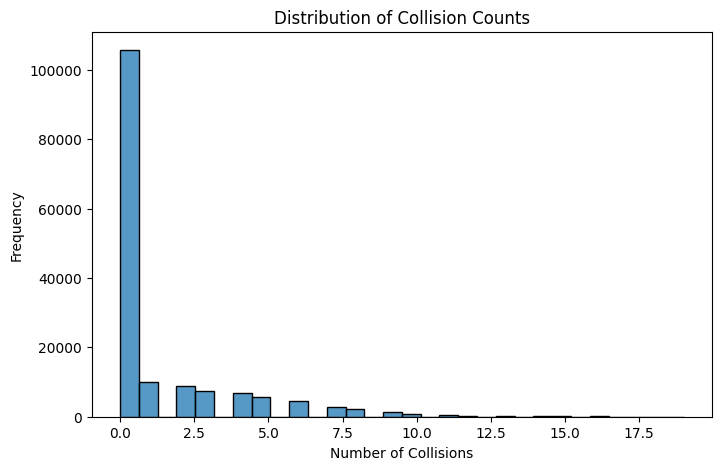

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["collision_count"], bins=30)

plt.title("Distribution of Collision Counts")

plt.xlabel("Number of Collisions")

plt.ylabel("Frequency")

plt.show()

Most observations have zero collisions and while only a small number of observations have one or more collisions.

#5. Collision by Hour

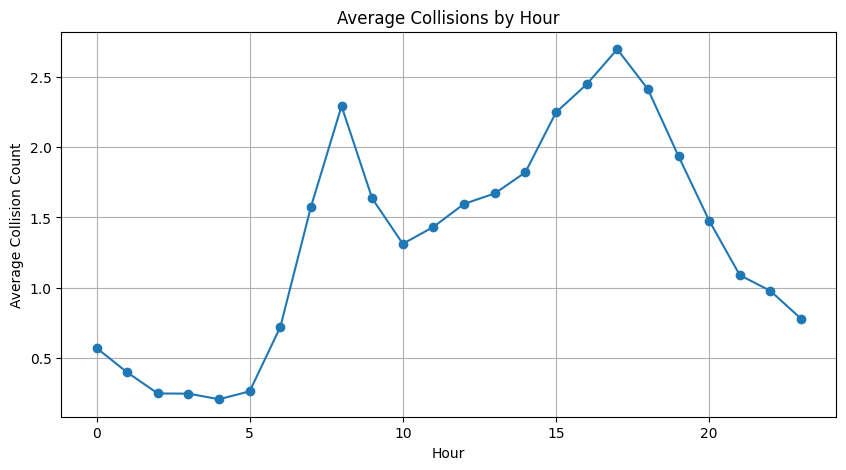

In [ ]:
hourly = (df.groupby("hour")["collision_count"].mean())

plt.figure(figsize=(10,5))

hourly.plot(marker="o")
plt.title("Average Collisions by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Collision Count")
plt.grid(True)
plt.show()

The average number of collisions is lowest during the early morning hours 2:00–5:00 AM and increases sharply during the daytime.

# 6. Collision by Day of Week

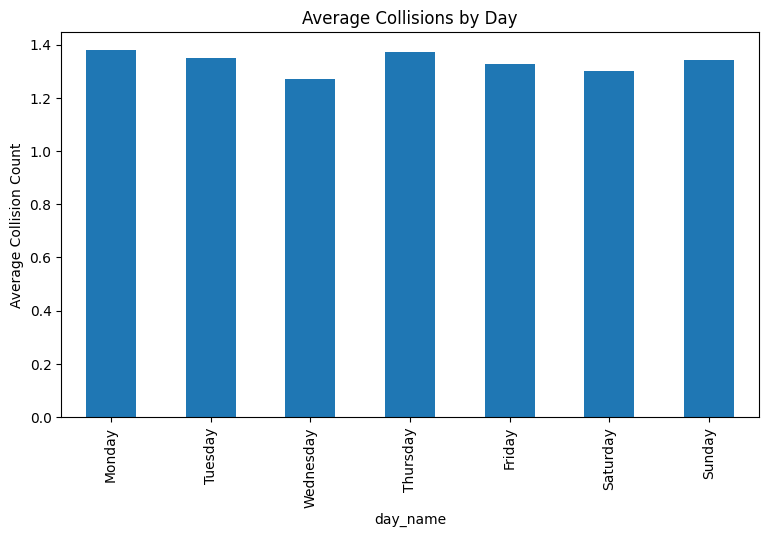

In [ ]:
weekday = (df.groupby("day_name")["collision_count"].mean())

weekday = weekday.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(9,5))

weekday.plot(kind="bar")

plt.title("Average Collisions by Day")

plt.ylabel("Average Collision Count")

plt.show()

The average collision count remains relatively consistent across all days of the week.

# 7. Collision by Season

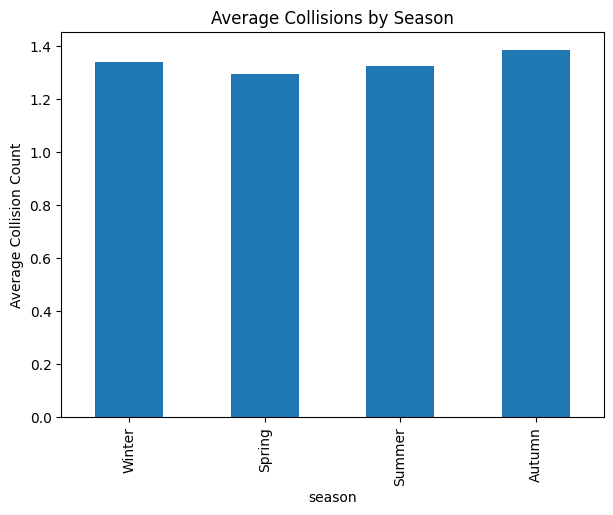

In [ ]:
season = (df.groupby("season")["collision_count"].mean())

season = season.reindex([
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
])

plt.figure(figsize=(7,5))

season.plot(kind="bar")

plt.title("Average Collisions by Season")

plt.ylabel("Average Collision Count")

plt.show()

The average collision count is relatively similar across all seasons and indicating that season alone has a limited effect on collision frequency.

# 8. Weekend vs Weekday

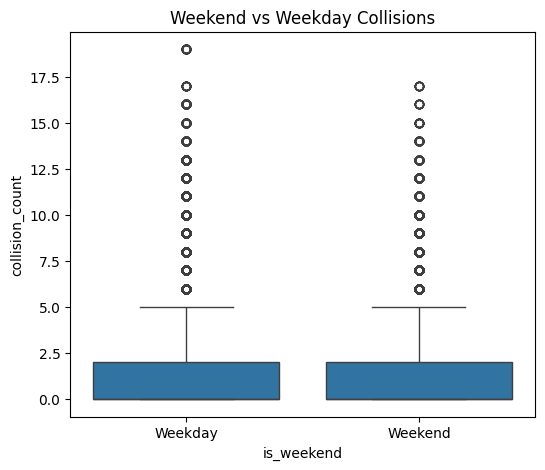

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(x="is_weekend",y="collision_count",data=df)

plt.xticks([0,1],["Weekday","Weekend"])

plt.title("Weekend vs Weekday Collisions")

plt.show()

The distribution of collision counts is very similar between weekdays and weekends.

#9. Air Quality Distribution

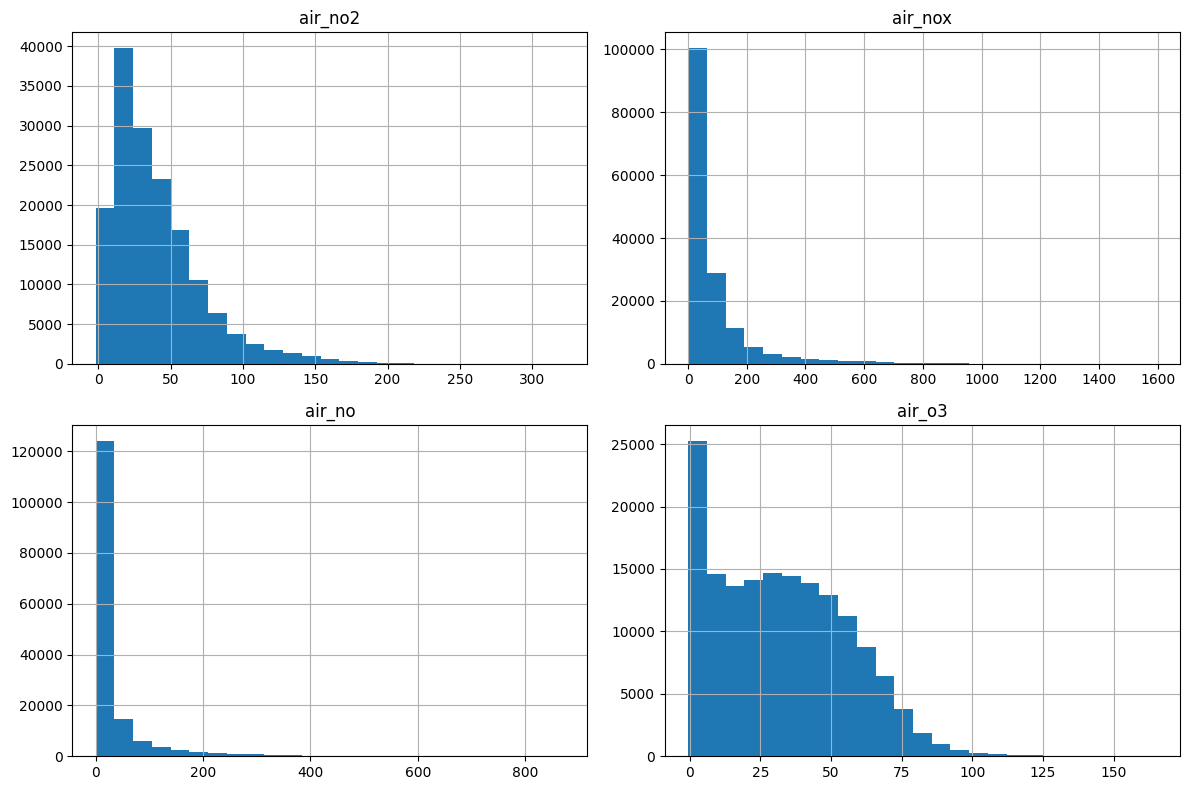

In [ ]:
air_features = [
    "air_no2",
    "air_nox",
    "air_no",
    "air_o3"
]

df[air_features].hist(figsize=(12,8),bins=25)

plt.tight_layout()

plt.show()

All air quality variables exhibit positively skewed distributions, where most observations are concentrated at low pollutant levels with a small number of high-concentration events.

# 10. Weather Features Distribution

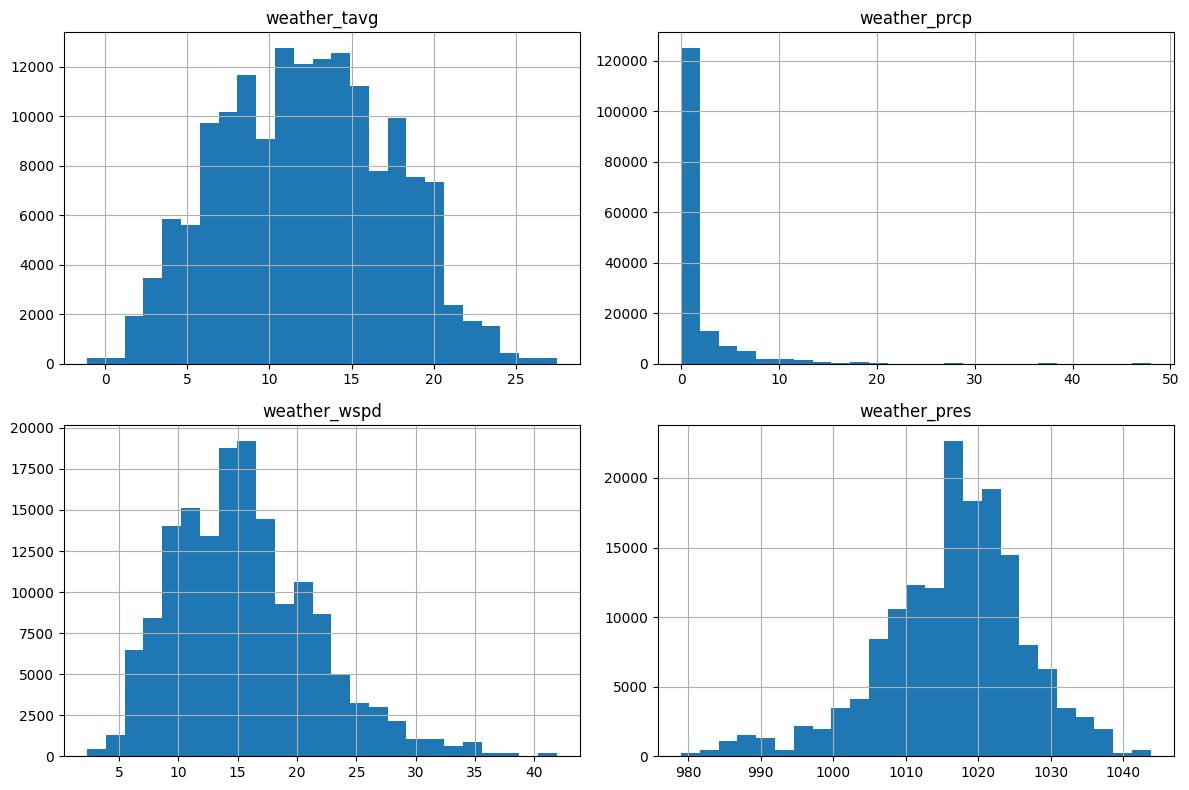

In [ ]:
weather_features = [
    "weather_tavg",
    "weather_prcp",
    "weather_wspd",
    "weather_pres"
]

df[weather_features].hist(figsize=(12,8),bins=25)

plt.tight_layout()

plt.show()

Most weather variables follow approximately normal distributions and while precipitation is highly right-skewed. This indicates that typical weather conditions are common and whereas heavy rainfall events are relatively rare.

# 11. Bike Count Distribution

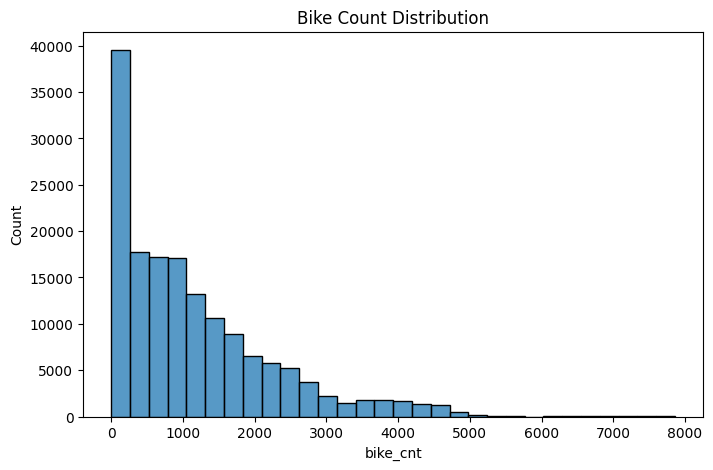

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["bike_cnt"],bins=30)

plt.title("Bike Count Distribution")

plt.show()

The bike count distribution is highly right-skewed and with most observations recording relatively low bike activity.

# 12. Correlation Matrix

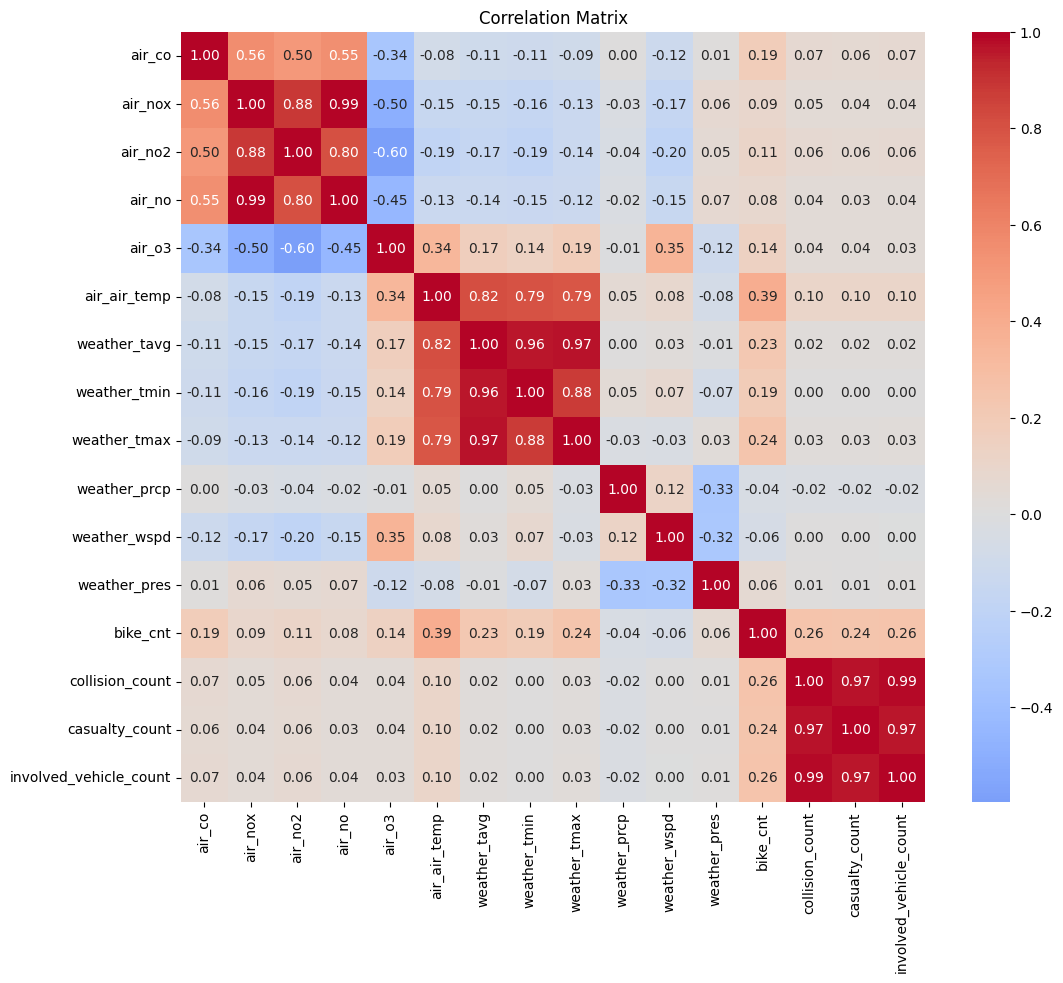

In [ ]:
corr_features = [
    "air_co",
    "air_nox",
    "air_no2",
    "air_no",
    "air_o3",
    "air_air_temp",

    "weather_tavg",
    "weather_tmin",
    "weather_tmax",
    "weather_prcp",
    "weather_wspd",
    "weather_pres",

    "bike_cnt",

    "collision_count",
    "casualty_count",
    "involved_vehicle_count"
]

plt.figure(figsize=(12,10))

sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

Collision count has a very strong positive correlation with casualty count 0.97 and involved vehicle count 0.99.air pollutants NOx, NO2, and NO are strongly correlated with each other.

# 13. Correlation with Collision Count

In [ ]:
# corr = (numeric.corr()["collision_count"].sort_values(ascending=False))
# corr

# 14 Top Correlated Features

In [ ]:
# plt.figure(figsize=(8,6))

# corr.drop("collision_count").head(10).plot(kind="barh")

# plt.title("Top Features Correlated with Collision Count")

# plt.show()

# 15 **Encoding, Split, Scaling, then PCA**

In [ ]:
# Prepare data for modeling
df_model = df.copy()

# Drop columns that are redundant or are outcomes of collisions (not predictors)
cols_to_drop_for_features = [
    'date',
    'day',
    'day_name',
    'bike_is_weekend',
    'bike_season',
    'casualty_count',
    'involved_vehicle_count'
]
df_model = df_model.drop(columns=cols_to_drop_for_features, errors='ignore')

# One-hot encode categorical features
categorical_cols = df_model.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, dtype=int)

# Define features (X) and target (y)
X = df_encoded.drop(columns=['collision_count'])
y = df_encoded['collision_count']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}")
print(f"Explained variance by principal components: {pca.explained_variance_ratio_.sum():.2f}")

Original number of features: 53
Number of features after PCA: 23
Explained variance by principal components: 0.96


lightgbm

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# predict whether a collision occurs at all
y_train_bin = (y_train > 0).astype(int)
y_test_bin = (y_test > 0).astype(int)

clf_stage1 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1
)
clf_stage1.fit(X_train, y_train_bin)

pred_prob_collision = clf_stage1.predict_proba(X_test)[:, 1]
pred_class_collision = (pred_prob_collision >= 0.5).astype(int)

# predict collision count, trained only on rows where collisions occurred
X_train_pos, X_val_pos, y_train_pos, y_val_pos = tts(
    X_train[y_train > 0],
    y_train[y_train > 0],
    test_size=0.15,
    random_state=42
)

reg_stage2 = lgb.LGBMRegressor(
    objective="tweedie",
    tweedie_variance_power=1.3,
    n_estimators=800,
    learning_rate=0.02,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1
)
reg_stage2.fit(
    X_train_pos, y_train_pos,
    eval_set=[(X_val_pos, y_val_pos)],
    eval_metric="tweedie",
    callbacks=[lgb.early_stopping(30, verbose=False)]
)

pred_count_if_collision = np.clip(reg_stage2.predict(X_test), 0, None)

# Combine stage 1 and stage 2 into final prediction
y_pred_hurdle = pred_class_collision * pred_count_if_collision

# Evaluation
mae_hurdle = mean_absolute_error(y_test, y_pred_hurdle)
mse_hurdle = mean_squared_error(y_test, y_pred_hurdle)
rmse_hurdle = np.sqrt(mse_hurdle)
r2_hurdle = r2_score(y_test, y_pred_hurdle)

print(f"MAE  : {mae_hurdle:.4f}")
print(f"MSE  : {mse_hurdle:.4f}")
print(f"RMSE : {rmse_hurdle:.4f}")
print(f"R2   : {r2_hurdle:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 41600, number of negative: 84716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035453 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3541
[LightGBM] [Info] Number of data points in the train set: 126316, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.329333 -> initscore=-0.711204
[LightGBM] [Info] Start training from score -0.711204
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3138
[LightGBM] [Info] Number of data points in the train set: 35360, number of used features: 53
[LightGBM] [Warning] Found whitespace in feature_names, 

LSTM

In [ ]:
import numpy as np
import tensorflow as tf
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score

# set seeds for reproducible results
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# reshape data for LSTM: (samples, timesteps, features)
X_train_lstm = X_train_pca.reshape(X_train_pca.shape[0], 1, X_train_pca.shape[1])
X_test_lstm = X_test_pca.reshape(X_test_pca.shape[0], 1, X_test_pca.shape[1])

# build the model with the best settings
lstm_model = Sequential()
lstm_model.add(LSTM(160, activation='tanh', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dropout(0.1))
lstm_model.add(Dense(16, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# stop early if validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# train the model
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stop],
    verbose=1
)

y_pred_lstm = lstm_model.predict(X_test_lstm)

mse_lstm = mean_squared_error(y_test, y_pred_lstm)
r2_lstm = r2_score(y_test, y_pred_lstm)

print(f"LSTM Mean Squared Error: {mse_lstm:.4f}")
print(f"LSTM R2: {r2_lstm:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - loss: 5.1999 - val_loss: 4.3971
Epoch 2/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 4.1730 - val_loss: 3.5975
Epoch 3/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 3.6046 - val_loss: 3.1443
Epoch 4/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 3.2205 - val_loss: 2.8036
Epoch 5/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 2.9471 - val_loss: 2.5743
Epoch 6/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 2.7524 - val_loss: 2.4362
Epoch 7/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 2.6031 - val_loss: 2.2821
Epoch 8/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 2.4649 - val_loss: 2.1614
Epoch 9/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 2.3667 - val_loss: 2.0664
Epoch 10/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 2.2659 - val_loss: 1.9957
Epoch 11/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 2.1838 - val_loss: 1.9301
Epoch 12/50
3948/39

FNN

In [ ]:
import numpy as np
import tensorflow as tf
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# set seeds for reproducible results
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# build the model using the best hyperparameters found from tuning
fnn_model = Sequential([
    Dense(160, activation='tanh', input_shape=(X_train_pca.shape[1],)),
    Dense(40, activation='tanh'),
    Dense(1)
])

fnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# stop training early if val_loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = fnn_model.fit(
    X_train_pca, y_train, epochs=50, batch_size=32,
    validation_data=(X_test_pca, y_test), verbose=1,
    callbacks=[early_stop]
)

y_pred_fnn = fnn_model.predict(X_test_pca)


from sklearn.metrics import mean_squared_error, r2_score

mse_fnn = mean_squared_error(y_test, y_pred_fnn)
r2_fnn = r2_score(y_test, y_pred_fnn)

print(f"\nFNN Mean Squared Error: {mse_fnn:.4f}")
print(f"FNN R2: {r2_fnn:.4f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3948/3948 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 5.2172 - val_loss: 4.3684
Epoch 2/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 3.9953 - val_loss: 3.4540
Epoch 3/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 3.2606 - val_loss: 2.9582
Epoch 4/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2.8293 - val_loss: 2.6380
Epoch 5/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2.5311 - val_loss: 2.3941
Epoch 6/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 2.3107 - val_loss: 2.2109
Epoch 7/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 2.1429 - val_loss: 2.0698
Epoch 8/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 2.0090 - val_loss: 1.9578
Epoch 9/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 1.8972 - val_loss: 1.8651
Epoch 10/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 1.8030 - val_loss: 1.7892
Epoch 11/50
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 1.7225 - val_loss: 1.7258
Epoch 12/50
3948/3948 ━━━━━━━━

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Evaluation

In [ ]:
from sklearn.metrics import (mean_absolute_error)

# Random Forest evaluation metrics
mae_rf = mean_absolute_error(y_test,y_pred_rf)

mse_rf = mean_squared_error(y_test,y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test,y_pred_rf)

print("Random Forest Results")
print(f"MAE  : {mae_rf:.4f}")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Results
MAE  : 1.1713
MSE  : 2.9575
RMSE : 1.7197
R²   : 0.5123


XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2,
    gamma=0.05,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

Evaluate

In [ ]:
# XGBoost evaluation metrics
mae_xgb = mean_absolute_error(y_test,y_pred_xgb)

mse_xgb = mean_squared_error(y_test,y_pred_xgb)

rmse_xgb = np.sqrt(mse_xgb)

r2_xgb = r2_score(y_test,y_pred_xgb)

print("XGBoost Results")
print(f"MAE  : {mae_xgb:.4f}")
print(f"MSE  : {mse_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

XGBoost Results
MAE  : 0.8051
MSE  : 1.6584
RMSE : 1.2878
R²   : 0.7265


#16. Compare All Models

In [ ]:
# Convert all values to one-dimensional arrays
y_test_array = np.asarray(y_test).reshape(-1)

y_pred_lstm_array = np.asarray(y_pred_lstm).reshape(-1)
y_pred_rf_array = np.asarray(y_pred_rf).reshape(-1)
y_pred_xgb_array = np.asarray(y_pred_xgb).reshape(-1)
y_pred_fnn_array = np.asarray(y_pred_fnn).reshape(-1)
y_pred_hurdle_array = np.asarray(y_pred_hurdle).reshape(-1)


# Function to calculate regression metrics
def evaluate_regression_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2


# LSTM evaluation
mae_lstm, mse_lstm, rmse_lstm, r2_lstm = evaluate_regression_model(
    y_test_array,
    y_pred_lstm_array
)

# Random Forest evaluation
mae_rf, mse_rf, rmse_rf, r2_rf = evaluate_regression_model(
    y_test_array,
    y_pred_rf_array
)

# XGBoost evaluation
mae_xgb, mse_xgb, rmse_xgb, r2_xgb = evaluate_regression_model(
    y_test_array,
    y_pred_xgb_array
)

# FNN evaluation
mae_fnn, mse_fnn, rmse_fnn, r2_fnn = evaluate_regression_model(
    y_test_array,
    y_pred_fnn_array
)

# LightGBM evaluation
mae_hurdle, mse_hurdle, rmse_hurdle, r2_hurdle = evaluate_regression_model(
    y_test_array,
    y_pred_hurdle_array
)


# Create comparison table
model_results = pd.DataFrame({
    "Model": [
        "LSTM",
        "Random Forest",
        "XGBoost",
        "FNN",
        "LightGBM"
    ],

    "MAE": [
        mae_lstm,
        mae_rf,
        mae_xgb,
        mae_fnn,
        mae_hurdle
    ],

    "MSE": [
        mse_lstm,
        mse_rf,
        mse_xgb,
        mse_fnn,
        mse_hurdle
    ],

    "RMSE": [
        rmse_lstm,
        rmse_rf,
        rmse_xgb,
        rmse_fnn,
        rmse_hurdle
    ],

    "R2 Score": [
        r2_lstm,
        r2_rf,
        r2_xgb,
        r2_fnn,
        r2_hurdle
    ]
})


# Sort from best to worst based on RMSE
model_results = model_results.sort_values(by="RMSE",ascending=True).reset_index(drop=True)


print("Model Comparison Results")

display(
    model_results.style.format({
        "MAE": "{:.4f}",
        "MSE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2 Score": "{:.4f}"
    })
)

Model Comparison Results


,Model,MAE,MSE,RMSE,R2 Score
0,LightGBM,0.3348,0.6003,0.7748,0.9010
1,FNN,0.7190,1.0842,1.0413,0.8212
2,LSTM,0.6273,1.1272,1.0617,0.8141
3,XGBoost,0.8051,1.6584,1.2878,0.7265
4,Random Forest,1.1713,2.9575,1.7197,0.5123


In [ ]:
# Select the Best Model
best_model_name = model_results.iloc[0]["Model"]
best_rmse = model_results.iloc[0]["RMSE"]
best_r2 = model_results.iloc[0]["R2 Score"]

print("Best Model Selection")

print(f"Best Model : {best_model_name}")
print(f"Best RMSE  : {best_rmse:.4f}")
print(f"R² Score   : {best_r2:.4f}")

Best Model Selection
Best Model : LightGBM
Best RMSE  : 0.7748
R² Score   : 0.9010


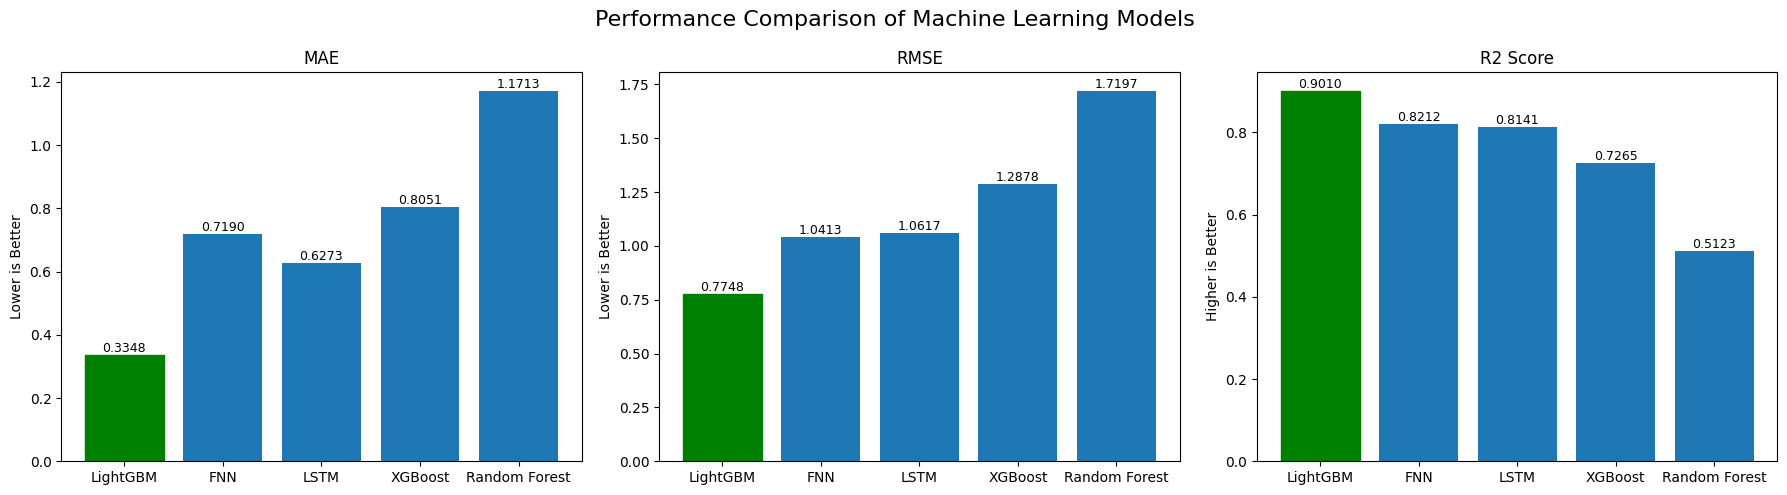

In [ ]:
# Metrics to compare
metrics = ["MAE", "RMSE", "R2 Score"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):

    values = model_results[metric]
    models = model_results["Model"]

    bars = axes[i].bar(models, values)

    # Highlight the best model
    if metric == "R2 Score":
        best_idx = values.idxmax()      # Higher is better
    else:
        best_idx = values.idxmin()      # Lower is better

    bars[best_idx].set_color("green")

    for j, bar in enumerate(bars):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{values.iloc[j]:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    axes[i].set_title(metric)

    if metric == "R2 Score":
        axes[i].set_ylabel("Higher is Better")
    else:
        axes[i].set_ylabel("Lower is Better")

plt.suptitle("Performance Comparison of Machine Learning Models", fontsize=16)

plt.tight_layout()

plt.show()

The results show that the LightGBM performed better than the other models. It had the lowest MAE and RMSE values which means it made more accurate predictions and it achieved the highest R2 score. And the LightGBM model was selected as the best model for this project.

# Final Insight

- The model LightGBM achieved the best overall performance among all the models.
- It recorded the lowest MAE and RMSE which means it made the most accurate predictions.
- It also achieved the highest R2 Score, outperforming LSTM, FNN, XGBoost and Random Forest.
- FNN and LSTM performed close to each other and were better than XGBoost and Random Forest.
- Random Forest showed the lowest performance among all the evaluated models.
- Based on the evaluation metrics and the LightGBM model was selected as the final model for predicting urban road collision risk in London.


# Conclusion

This project explored how machine learning can be used to predict road collision risk in London using air quality, weather, bike-sharing and accident data. After preprocessing the data, five models (LSTM, Random Forest, XGBoost, FNN and a LightGBM model) were trained and compared. Since most of the collision data was zero most of the time, the LightGBM model handled this better by first predicting if a collision happens and then predicting how many. Based on the evaluation results the LightGBM model was selected as the best model. Overall this project shows how machine learning can support safer transportation and smarter urban planning.

In [ ]:
# Save and download the best model
import shutil
import joblib
from google.colab import files

# اسم المجلد الذي سنحفظ فيه أفضل مودل
save_folder = "saved_models"

# حذف المجلد القديم حتى لا تبقى فيه موديلات محفوظة سابقًا
if os.path.exists(save_folder):
    shutil.rmtree(save_folder)

# إنشاء مجلد جديد وفارغ
os.makedirs(save_folder, exist_ok=True)

# اختيار أفضل مودل بناءً على أقل RMSE
best_model_name = model_results.loc[
    model_results["RMSE"].idxmin(),
    "Model"
]

print("Best Model:", best_model_name)

# حفظ أفضل مودل فقط
if best_model_name == "LSTM":

    best_model_path = os.path.join(
        save_folder,
        "best_model.keras"
    )

    lstm_model.save(best_model_path)

elif best_model_name == "Random Forest":

    best_model_path = os.path.join(
        save_folder,
        "best_model.pkl"
    )

    joblib.dump(
        rf_model,
        best_model_path
    )

elif best_model_name == "XGBoost":

    best_model_path = os.path.join(
        save_folder,
        "best_model.json"
    )

    xgb_model.save_model(best_model_path)

elif best_model_name == "FNN":

    best_model_path = os.path.join(
        save_folder,
        "best_model.keras"
    )

    fnn_model.save(best_model_path)

elif best_model_name == "Hurdle (LightGBM)":

    stage1_path = os.path.join(
        save_folder,
        "best_model_stage1.pkl"
    )

    stage2_path = os.path.join(
        save_folder,
        "best_model_stage2.pkl"
    )

    joblib.dump(clf_stage1, stage1_path)
    joblib.dump(reg_stage2, stage2_path)

    best_model_path = f"{stage1_path}, {stage2_path}"

else:
    raise ValueError(
        f"Unknown model name: {best_model_name}"
    )

# حفظ اسم أفضل مودل حتى يعرف Streamlit نوعه
model_name_path = os.path.join(
    save_folder,
    "best_model_name.txt"
)

with open(model_name_path, "w", encoding="utf-8") as file:
    file.write(best_model_name)

print("\nBest model saved successfully.")
print("Saved model:", best_model_path)
print("Saved model name:", model_name_path)

# ضغط مجلد أفضل مودل
zip_file = shutil.make_archive(
    "smart_london_best_model",
    "zip",
    save_folder
)

print("\nZIP file created:", zip_file)

# تحميل الملف المضغوط
files.download(zip_file)

Best Model: Hurdle (LightGBM)

Best model saved successfully.
Saved model: saved_models/best_model_stage1.pkl, saved_models/best_model_stage2.pkl
Saved model name: saved_models/best_model_name.txt

ZIP file created: /content/smart_london_best_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>